# Modelo Transformers

In [2]:
# Librerías
import os, gc
from pathlib import Path
import numpy as np
import pandas as pd
import torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, TrainerCallback
)
import evaluate


In [3]:
# Carga y limpieza desde único dataset
DATA_PATH = Path(r"C:\Users\Sistemas\Desktop\PFINAL\nuevo_df.csv")
df = pd.read_csv(DATA_PATH)

# Limpieza mínima
df['texto_completo'] = df['clean_text'].fillna('').str.strip()
df['Nivel_f']        = df['Nivel_f'].fillna('').str.strip()

# Codificación de etiquetas
label_encoder  = LabelEncoder()
df['label']    = label_encoder.fit_transform(df['Nivel_f'])

print("Clases codificadas:", dict(enumerate(label_encoder.classes_)))


Clases codificadas: {0: 'Alto', 1: 'Bajo', 2: 'Medio alto', 3: 'Medio bajo'}


In [4]:
# División de train / val / test (desde un solo dataset)
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

# Validación
train_df, val_df = train_test_split(
    train_df, test_size=0.1, random_state=42, stratify=train_df['label']
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 1382 | Val: 154 | Test: 384


In [5]:
# Pesos de clase (para la pérdida)
class_weights = torch.tensor(
    compute_class_weight(class_weight='balanced',
                         classes=np.unique(train_df['label']),
                         y=train_df['label']),
    dtype=torch.float)


In [6]:
# Búsqueda de hiperparámetros
from itertools import product
from copy import deepcopy
from tqdm import tqdm

param_grid = {
    "learning_rate": [1e-5, 3e-5],  # Aprendizaje más lento estabiliza
    "per_device_train_batch_size": [8, 16],  # Más pequeño = más ruido = más generalización
    "num_train_epochs": [10],
    "weight_decay": [0.01, 0.1, 0.2],
    "lr_scheduler_type": ["cosine"],  # Cosine decae mejor con menos overfitting
    "warmup_ratio": [0.05, 0.1],
    "gradient_accumulation_steps": [2, 3],  # Simula batch más grande
    "fp16": [True],  # Usa media precisión para estabilidad con GPU
}

# Generar combinaciones de hiperparámetros
keys = list(param_grid.keys())
combinations = list(product(*param_grid.values()))
print(f"Total combinaciones a evaluar: {len(combinations)}")


Total combinaciones a evaluar: 48


In [7]:
# Tokenizador y modelo base
model_name = "dccuchile/bert-base-spanish-wwm-cased"
# model_name = "PlanTL-GOB-ES/roberta-base-bne"

tokenizer  = AutoTokenizer.from_pretrained(model_name)
model_base = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=len(label_encoder.classes_)
)

# Conversión a datasets
def to_hfds(df):
    return Dataset.from_pandas(df[['texto_completo', 'label']])

train_ds = to_hfds(train_df)
val_ds   = to_hfds(val_df)
test_ds  = to_hfds(test_df)

# Tokenización
def tok(batch):
    return tokenizer(
        batch["texto_completo"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

def tok2(batch):
    return tokenizer(batch["texto_completo"],
                    truncation=True,
                    padding="max_length",
                    max_length=512,
                    
# Estos para SLIDING WINDOW -----------------------               
                    stride=128,
                    return_overflowing_tokens=True,
                    return_special_tokens_mask=True)

train_ds = train_ds.map(tok, batched=True).remove_columns("texto_completo")
val_ds   = val_ds.map(tok, batched=True).remove_columns("texto_completo")
#test_ds  = test_ds.map(tok, batched=True).remove_columns("texto_completo")



# Para SLIDING WIENDOW ---------------------------
from collections import defaultdict

# Crear dataset de test manualmente (sin modificar el original)
test_ds_windowed = Dataset.from_pandas(test_df[['texto_completo', 'label']])

# Tokenizar con sliding window
tokenized_test = tokenizer(
    test_ds_windowed["texto_completo"],
    truncation=True,
    padding="max_length",
    max_length=512,
    stride=128,
    return_overflowing_tokens=True,
    return_special_tokens_mask=True,
    return_tensors=None
)

# Guardar mapeo de fragmentos a textos originales
test_ds_windowed = test_ds_windowed.map(tok2, batched=True)
sample_mapping = test_ds_windowed["overflow_to_sample_mapping"]
test_ds_windowed = test_ds_windowed.remove_columns("texto_completo")
test_ds_windowed.set_format("torch")

# Formato PyTorch
for ds in (train_ds, val_ds, test_ds):
    ds.set_format("torch")

# Métricas
accuracy  = evaluate.load("accuracy")
f1        = evaluate.load("f1")
precision = evaluate.load("precision")
recall    = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy"        : accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro"        : f1.compute(predictions=preds, references=labels, average="macro")["f1"],
        "precision_macro" : precision.compute(predictions=preds, references=labels, average="macro")["precision"],
        "recall_macro"    : recall.compute(predictions=preds, references=labels, average="macro")["recall"],
    }

class MetricPrinter(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None: return
        print(f"Época {int(state.epoch):>2} | "
              f"Acc={metrics.get('eval_accuracy', 0):.4f}  "
              f"F1={metrics.get('eval_f1_macro', 0):.4f}  "
              f"Prec={metrics.get('eval_precision_macro', 0):.4f}  "
              f"Rec={metrics.get('eval_recall_macro', 0):.4f}")


# Trainer personalizado con pérdida focalizada
class FocalLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        ce_loss = nn.functional.cross_entropy(logits, labels, weight=class_weights.to(model.device), reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** 2 * ce_loss).mean()
        return (focal_loss, outputs) if return_outputs else focal_loss


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 384/384 [00:00<00:00, 3134.24 examples/s]


In [8]:
# Parámetros de entrenamiento
out_root = r"C:\Users\Sistemas\Desktop\beto solo grid\out beto grid 1"
os.makedirs(out_root, exist_ok=True)
resultados_grid = []

for i, valores in enumerate(tqdm(combinations, desc="🔁 Ejecutando combinaciones")):
    params = dict(zip(keys, valores))
    print(f"\nCombinación {i+1}/{len(combinations)}: {params}")

    output_dir_i = os.path.join(out_root, f"beto_grid_run_{i}")
    os.makedirs(output_dir_i, exist_ok=True)

    training_args = TrainingArguments(
        output_dir=output_dir_i,
        evaluation_strategy="epoch",
        save_strategy="no",
        logging_strategy="no",
        learning_rate=params["learning_rate"],
        per_device_train_batch_size=params["per_device_train_batch_size"],
        per_device_eval_batch_size=8,
        num_train_epochs=params["num_train_epochs"],
        weight_decay=params["weight_decay"],
        lr_scheduler_type=params["lr_scheduler_type"],
        load_best_model_at_end=False,
        seed=42,
        warmup_ratio=params["warmup_ratio"],
        gradient_accumulation_steps=params["gradient_accumulation_steps"],
        fp16=params["fp16"],
        disable_tqdm=True
    )

    trainer = FocalLossTrainer(
        model=deepcopy(model_base),
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )

    trainer.train()
    metrics = trainer.evaluate()
    resultados_grid.append({**params, **metrics})

    # Liberar memoria
    del trainer
    torch.cuda.empty_cache()
    gc.collect()



🔁 Ejecutando combinaciones:   0%|          | 0/48 [00:00<?, ?it/s]c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\transformers\training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(



Combinación 1/48: {'learning_rate': 1e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 10, 'weight_decay': 0.01, 'lr_scheduler_type': 'cosine', 'warmup_ratio': 0.05, 'gradient_accumulation_steps': 2, 'fp16': True}


C:\Users\Sistemas\AppData\Local\Temp\ipykernel_8796\1810198055.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalLossTrainer.__init__`. Use `processing_class` instead.
  trainer = FocalLossTrainer(


{'eval_loss': 0.5462207794189453, 'eval_accuracy': 0.3181818181818182, 'eval_f1_macro': 0.30134562407289683, 'eval_precision_macro': 0.30928030303030307, 'eval_recall_macro': 0.48229020979020976, 'eval_runtime': 0.8045, 'eval_samples_per_second': 191.416, 'eval_steps_per_second': 24.859, 'epoch': 0.9942196531791907}
{'eval_loss': 0.5684167146682739, 'eval_accuracy': 0.34415584415584416, 'eval_f1_macro': 0.3443694819257038, 'eval_precision_macro': 0.4213046202462678, 'eval_recall_macro': 0.4466083916083916, 'eval_runtime': 0.8063, 'eval_samples_per_second': 190.999, 'eval_steps_per_second': 24.805, 'epoch': 2.0}
{'eval_loss': 0.5240020155906677, 'eval_accuracy': 0.4155844155844156, 'eval_f1_macro': 0.4195698583387665, 'eval_precision_macro': 0.4803040255927794, 'eval_recall_macro': 0.5176398601398602, 'eval_runtime': 0.7864, 'eval_samples_per_second': 195.82, 'eval_steps_per_second': 25.431, 'epoch': 2.994219653179191}
{'eval_loss': 0.555910587310791, 'eval_accuracy': 0.4415584415584415

🔁 Ejecutando combinaciones:   2%|▏         | 1/48 [04:21<3:24:46, 261.41s/it]c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\transformers\training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\Sistemas\AppData\Local\Temp\ipykernel_8796\1810198055.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalLossTrainer.__init__`. Use `processing_class` instead.
  trainer = FocalLossTrainer(


...

🔁 Ejecutando combinaciones:  98%|█████████▊| 47/48 [3:11:11<03:53, 233.96s/it]c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\transformers\training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\Sistemas\AppData\Local\Temp\ipykernel_8796\1810198055.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalLossTrainer.__init__`. Use `processing_class` instead.
  trainer = FocalLossTrainer(



Combinación 48/48: {'learning_rate': 3e-05, 'per_device_train_batch_size': 16, 'num_train_epochs': 10, 'weight_decay': 0.2, 'lr_scheduler_type': 'cosine', 'warmup_ratio': 0.1, 'gradient_accumulation_steps': 3, 'fp16': True}


c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'eval_loss': 0.5987407565116882, 'eval_accuracy': 0.2792207792207792, 'eval_f1_macro': 0.23244219894937598, 'eval_precision_macro': 0.27927863541071085, 'eval_recall_macro': 0.4518181818181818, 'eval_runtime': 0.7628, 'eval_samples_per_second': 201.89, 'eval_steps_per_second': 26.219, 'epoch': 1.0}
{'eval_loss': 0.49473699927330017, 'eval_accuracy': 0.4025974025974026, 'eval_f1_macro': 0.4172141264532569, 'eval_precision_macro': 0.46357379179959823, 'eval_recall_macro': 0.49979020979020977, 'eval_runtime': 0.7831, 'eval_samples_per_second': 196.657, 'eval_steps_per_second': 25.54, 'epoch': 2.0}
{'eval_loss': 0.5780852437019348, 'eval_accuracy': 0.4155844155844156, 'eval_f1_macro': 0.42258075094277747, 'eval_precision_macro': 0.4231709956709957, 'eval_recall_macro': 0.4966083916083916, 'eval_runtime': 0.8027, 'eval_samples_per_second': 191.857, 'eval_steps_per_second': 24.917, 'epoch': 3.0}
{'eval_loss': 0.5407264828681946, 'eval_accuracy': 0.43506493506493504, 'eval_f1_macro': 0.44394

🔁 Ejecutando combinaciones: 100%|██████████| 48/48 [3:15:03<00:00, 243.83s/it]


In [9]:
# Guardado de resultados
df_resultados = pd.DataFrame(resultados_grid)
df_ordenado = df_resultados.sort_values("eval_f1_macro", ascending=False)

print("\nTop combinaciones por F1 macro:")
print(df_ordenado[[
    "eval_f1_macro", "eval_accuracy", "learning_rate",
    "per_device_train_batch_size", "num_train_epochs",
    "weight_decay", "lr_scheduler_type"
]].head(5).round(4))

csv_path = os.path.join(out_root, "resultados_beto_grid_search.csv")
df_ordenado.to_csv(csv_path, index=False)
print(f"Resultados guardados en: {csv_path}")



Top combinaciones por F1 macro:
    eval_f1_macro  eval_accuracy  learning_rate  per_device_train_batch_size  \
2          0.5412         0.5325            0.0                            8   
6          0.5412         0.5325            0.0                            8   
10         0.5412         0.5325            0.0                            8   
4          0.5348         0.5260            0.0                            8   
8          0.5348         0.5260            0.0                            8   

    num_train_epochs  weight_decay lr_scheduler_type  
2                 10          0.01            cosine  
6                 10          0.10            cosine  
10                10          0.20            cosine  
4                 10          0.10            cosine  
8                 10          0.20            cosine  
Resultados guardados en: C:\Users\Sistemas\Desktop\beto solo grid\out beto grid 1\resultados_beto_grid_search.csv


In [10]:
# Entrenamiento con hiperparámetros seleccionados
mejores_params = df_ordenado.iloc[0][keys].to_dict()
print("\nMejor combinación encontrada:")
print(mejores_params)

# Ruta final de salida
output_dir_final = os.path.join(out_root, "beto_modelo_final")
os.makedirs(output_dir_final, exist_ok=True)

training_args_final = TrainingArguments(
    output_dir=output_dir_final,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    learning_rate=mejores_params["learning_rate"],
    per_device_train_batch_size=mejores_params["per_device_train_batch_size"],
    per_device_eval_batch_size=8,
    num_train_epochs=mejores_params["num_train_epochs"],
    weight_decay=mejores_params["weight_decay"],
    lr_scheduler_type=mejores_params["lr_scheduler_type"],
    warmup_ratio=mejores_params["warmup_ratio"],  # NUEVO
    gradient_accumulation_steps=mejores_params["gradient_accumulation_steps"],  # NUEVO
    fp16=mejores_params["fp16"],  # NUEVO
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    seed=42
)

# Entrenador final ----------------------------
trainer_final = FocalLossTrainer(
    model=deepcopy(model_base),
    args=training_args_final,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2),
               MetricPrinter()]
)

# Entrenamiento completo
trainer_final.train()
print("Evaluación final en validación:", trainer_final.evaluate())


c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\transformers\training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\Sistemas\AppData\Local\Temp\ipykernel_8796\224222461.py:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalLossTrainer.__init__`. Use `processing_class` instead.
  trainer_final = FocalLossTrainer(



Mejor combinación encontrada:
{'learning_rate': 1e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 10, 'weight_decay': 0.01, 'lr_scheduler_type': 'cosine', 'warmup_ratio': 0.1, 'gradient_accumulation_steps': 2, 'fp16': True}


  1%|          | 10/860 [00:02<04:07,  3.43it/s]

{'loss': 1.646, 'grad_norm': 11.823606491088867, 'learning_rate': 1.1627906976744188e-06, 'epoch': 0.12}


  2%|▏         | 20/860 [00:05<04:03,  3.45it/s]

...

{'eval_loss': 0.6690161228179932, 'eval_accuracy': 0.5324675324675324, 'eval_f1_macro': 0.5412097963611961, 'eval_precision_macro': 0.5314864864864866, 'eval_recall_macro': 0.5784265734265734, 'eval_runtime': 0.7872, 'eval_samples_per_second': 195.634, 'eval_steps_per_second': 25.407, 'epoch': 9.94}
Época  9 | Acc=0.5325  F1=0.5412  Prec=0.5315  Rec=0.5784


100%|██████████| 860/860 [04:32<00:00,  3.15it/s]


{'train_runtime': 272.8662, 'train_samples_per_second': 50.648, 'train_steps_per_second': 3.152, 'train_loss': 0.6709657459758048, 'epoch': 9.94}


100%|██████████| 20/20 [00:00<00:00, 27.06it/s]

Época  9 | Acc=0.5325  F1=0.5412  Prec=0.5315  Rec=0.5784
Evaluación final en validación: {'eval_loss': 0.6690161228179932, 'eval_accuracy': 0.5324675324675324, 'eval_f1_macro': 0.5412097963611961, 'eval_precision_macro': 0.5314864864864866, 'eval_recall_macro': 0.5784265734265734, 'eval_runtime': 0.8021, 'eval_samples_per_second': 191.988, 'eval_steps_per_second': 24.934, 'epoch': 9.942196531791907}


100%|██████████| 48/48 [00:01<00:00, 25.60it/s]



Tabla de métricas (Test final):

Model Type        Class precision    recall        f1 support  accuracy  log_loss       auc
 BETO test         Alto  0.299213  0.678571  0.415301      56         -         -  0.782992
 BETO test         Bajo  0.729167  0.564516  0.636364      62         -         -  0.893308
 BETO test   Medio alto  0.428571  0.328467  0.371901     137         -         -  0.608795
 BETO test   Medio bajo  0.557692  0.449612  0.497854     129         -         -  0.713938
 BETO test    macro avg  0.503661  0.505292  0.480355     384         -         -  0.749758
 BETO test weighted avg  0.501617  0.458333  0.463242     384         -         -         -
 BETO test       global         -         -         -       -  0.458333  1.192515  0.757994

Métricas guardadas en: C:\Users\Sistemas\Desktop\beto solo grid\out beto grid 1\beto_modelo_final\metricas_test_final.csv


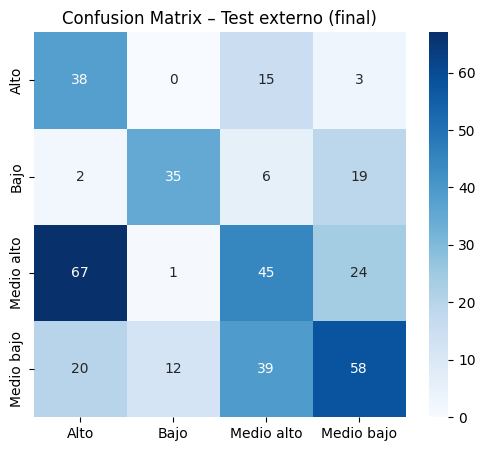

In [ ]:
# Para SLIDING WINDOW------------------------
preds_test = trainer_final.predict(test_ds_windowed)
logits = preds_test.predictions
labels = preds_test.label_ids

# Agrupar logits por texto original y promediar
logits_por_texto = defaultdict(list)
labels_por_texto = {}

for i, idx in enumerate(sample_mapping):
    logits_por_texto[idx].append(logits[i])
    labels_por_texto[idx] = labels[i]

# Promediar logits y reconstruir predicción final
y_logits = []
y_true   = []
for idx in sorted(logits_por_texto):
    media_logits = np.mean(logits_por_texto[idx], axis=0)
    y_logits.append(media_logits)
    y_true.append(labels_por_texto[idx])

y_logits = np.array(y_logits)
y_pred   = np.argmax(y_logits, axis=-1)
y_true   = np.array(y_true)


# Métricas y tabla
from sklearn.metrics import (
    roc_auc_score, log_loss,
    precision_recall_fscore_support, accuracy_score
)

probas = torch.softmax(torch.tensor(y_logits), dim=-1).numpy()

prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred,
    labels=np.arange(len(label_encoder.classes_)),
    zero_division=0
)
auc_per_class = roc_auc_score(
    y_true, probas, multi_class="ovr", average=None
)

rows = []
for idx, cls_name in enumerate(label_encoder.classes_):
    rows.append(dict(
        Model="BETO",
        Type="test",
        Class=cls_name,
        precision=prec[idx],
        recall=rec[idx],
        f1=f1[idx],
        support=support[idx],
        accuracy="-",
        log_loss="-",
        auc=auc_per_class[idx]
    ))

prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)
auc_macro = roc_auc_score(y_true, probas, multi_class="ovr", average="macro")
auc_micro = roc_auc_score(y_true, probas, multi_class="ovr", average="micro")
acc       = accuracy_score(y_true, y_pred)
lloss     = log_loss(y_true, probas)

rows += [
    dict(Model="BETO", Type="test", Class="macro avg",
         precision=prec_m, recall=rec_m, f1=f1_m,
         support=support.sum(), accuracy="-", log_loss="-", auc=auc_macro),
    dict(Model="BETO", Type="test", Class="weighted avg",
         precision=prec_w, recall=rec_w, f1=f1_w,
         support=support.sum(), accuracy="-", log_loss="-", auc="-"),
    dict(Model="BETO", Type="test", Class="global",
         precision="-", recall="-", f1="-", support="-",
         accuracy=acc, log_loss=lloss, auc=auc_micro)
]

metric_df = pd.DataFrame(rows)

# Mostrar tabla
pd.set_option("display.max_columns", None)
print("\nTabla de métricas (Test final):\n")
print(metric_df.round(3).to_string(index=False))

# Guardado en csv para usarlo -------------
metric_df.to_csv(os.path.join(output_dir_final, "metricas_test_final.csv"), index=False)
print(f"\nMétricas guardadas en: {output_dir_final}\\metricas_test_final.csv")

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix – Test externo (final)")
plt.show()


       epoch  eval_accuracy  eval_loss
8   0.994220       0.279221   0.607092
18  2.000000       0.350649   0.553005
27  2.994220       0.350649   0.515466
37  4.000000       0.467532   0.526092
47  4.994220       0.428571   0.552636
56  6.000000       0.487013   0.586901
66  6.994220       0.512987   0.633056
76  8.000000       0.525974   0.658094
85  8.994220       0.525974   0.665847
95  9.942197       0.532468   0.669016
97  9.942197       0.532468   0.669016
Épocas: [0.99421965 2.         2.99421965 4.         4.99421965 6.
 6.99421965 8.         8.99421965 9.94219653 9.94219653]
Accuracy: [0.27922078 0.35064935 0.35064935 0.46753247 0.42857143 0.48701299
 0.51298701 0.52597403 0.52597403 0.53246753 0.53246753]
Loss: [0.60709172 0.55300534 0.51546609 0.52609181 0.55263561 0.58690101
 0.63305616 0.65809405 0.66584659 0.66901612 0.66901612]


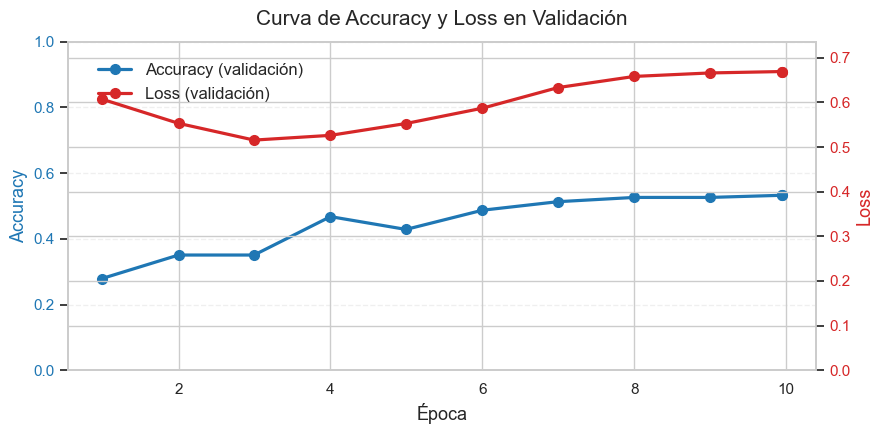

In [ ]:
# Curva de Accuracy y Loss en Validación – Visualización profesional adaptada
if hasattr(trainer_final, 'state') and hasattr(trainer_final.state, 'log_history'):
    history = pd.DataFrame(trainer_final.state.log_history)
    print(history[['epoch', 'eval_accuracy', 'eval_loss']].dropna())

    df_eval = history.loc[history['eval_accuracy'].notnull(), ['epoch', 'eval_accuracy', 'eval_loss']]
    
    epochs  = df_eval['epoch'].values
    accs    = df_eval['eval_accuracy'].values
    losses  = df_eval['eval_loss'].values
    
    print("Épocas:", epochs)
    print("Accuracy:", accs)
    print("Loss:", losses)
else:
    print("No se encontró historial de entrenamiento.")

# visualización
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(9, 4.5))

# Curva de accuracy
color_acc = '#1f77b4'
ax1.plot(epochs, accs, marker='o', linewidth=2.3, markersize=7, color=color_acc, label='Accuracy (validación)')
ax1.set_xlabel("Época", fontsize=13)
ax1.set_ylabel("Accuracy", color=color_acc, fontsize=13)
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.set_ylim(0, 1)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Curva de loss
ax2 = ax1.twinx()
color_loss = "#d64a27"
ax2.plot(epochs, losses, marker='o', linewidth=2.3, markersize=7, color=color_loss, label='Loss (validación)')
ax2.set_ylabel("Loss", color=color_loss, fontsize=13)
ax2.tick_params(axis='y', labelcolor=color_loss)
ax2.set_ylim(0, max(losses)*1.1)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', bbox_to_anchor=(0.02, 0.98), fontsize=12, frameon=False)

plt.title("Curva de Accuracy y Loss en Validación", fontsize=15, pad=12)
plt.tight_layout()
plt.show()


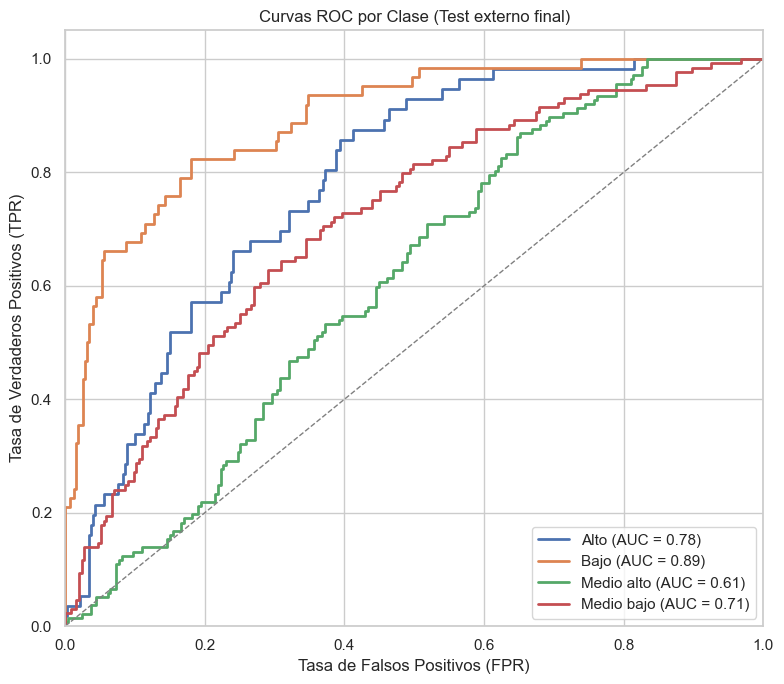

In [13]:
# Curvas ROC por clase (Test externo)
from sklearn.metrics import roc_curve, auc

n_classes = len(label_encoder.classes_)
plt.figure(figsize=(8, 7))

for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve((y_true == i).astype(int), probas[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curvas ROC por Clase (Test externo final)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
